<img src="Logo.png" width="100" align="left"/> 

# <center> Unit 3 Project </center>
#  <center> First section : Data cleaning  </center>

In this notebook you will be cleaning your dataset and making sure it's fully ready for modeling.

The used dataset is [Hepatitis C  dataset](https://www.kaggle.com/fedesoriano/hepatitis-c-dataset)

## Data preparation 
As a first step we need to prepare the data :

1. Read the data set as a data frame ( file name is HepatitisCdata.csv) 
2. The here are the column of your dataset:
    1) X (Patient ID/No.)
    2) Category (diagnosis) (values: '0=Blood Donor', '0s=suspect Blood Donor', '1=Hepatitis', '2=Fibrosis', '3=Cirrhosis') ( the target ) 
    3) Age (in years)
    4) Sex (f,m)
    Attributes 5 to 14 refer to laboratory data:
    5) ALB : Albumin Blood Test
    6) ALP : Alkaline phosphatase
    7) ALT : Alanine Transaminase
    8) AST : Aspartate Transaminase
    9) BIL : Bilirubin
    10) CHE : Acetylcholinesterase
    11) CHOL : Cholesterol
    12) CREA : Creatinine 
    13) GGT : Gamma-Glutamyl Transferase
    14) PROT : Proteins
    
3. Remember your model only accepts numbers so make sure you deal properly with the missing values and the data types and justify your solution choices 
 
4. Make sure the dataset shape in the end is : rows 615 and  14 columns 
 
5. Once finished save the cleaned dataset as "clean_HepatitisC.csv" file 
 

In [93]:
import pandas as pd 
import numpy as np 

In [94]:
#To-Do: read the dataset 
data = pd.read_csv('HepatitisCdata.csv')

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [96]:
#To-Do  Start investigating the data types and correcting that 
# Provide explanation about each step in Markdown cells 

#### Data Encoding

1. The dataset contains two categorical columns: **`Sex`** and the target column **`Category`**, both of which need to be encoded.
2. The **`Category`** column is the target variable, so I encoded it using **LabelEncoder**, which is the standard approach for encoding target labels in classification tasks.
3. The **`Sex`** column contains only two unique values (`'m'` and `'f'`), so I also encoded it using **LabelEncoder**, as binary categorical features can be represented efficiently with integer labels.


In [97]:
# Import LabelEncoder from Sklearn
from sklearn.preprocessing import LabelEncoder

# Investigate categorical columns
data['Sex'].unique()
data['Category'].unique()

# Create Label Encoder object
le = LabelEncoder()

# Encode 'Category' and 'Sex' using Label Encoder
data["Category"] = le.fit_transform(data["Category"])
data["Sex"] = le.fit_transform(data["Sex"])

# Confirm that all columns are now numerical
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    int64  
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    int64  
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 67.4 KB


> Data types are all numeric Now ! Next we need to deal with missing values for the feature columns 

#To-Do list all the columns that contain missing values along with their counts 

In [98]:
# To-Do Start providing solutions for each column that has missing data 
# Treat each case seperately 
# Hint : no data row should be deleted 
# Provide evidence that you filled those missing values after each step 

### Handle Missing Values

1. I examined the dataset and identified all columns containing missing values, along with the number of missing entries in each column.
2. I created histograms and boxplots for the five columns with missing values to inspect their distributions and identify potential outliers.
3. I chose **median imputation** to replace the missing values. Laboratory measurements often have skewed distributions and contain outliers, making the median a more robust choice than the mean.
4. I verified that all missing values were successfully imputed and confirmed that no missing values remained in the dataset.


List of columns with missing values:
 ALB      1
ALP     18
ALT      1
CHOL    10
PROT     1
dtype: int64


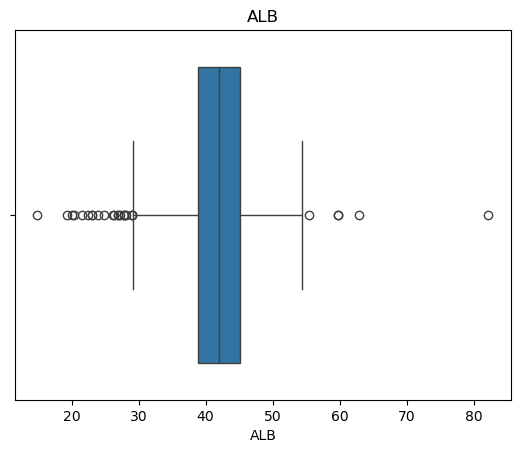

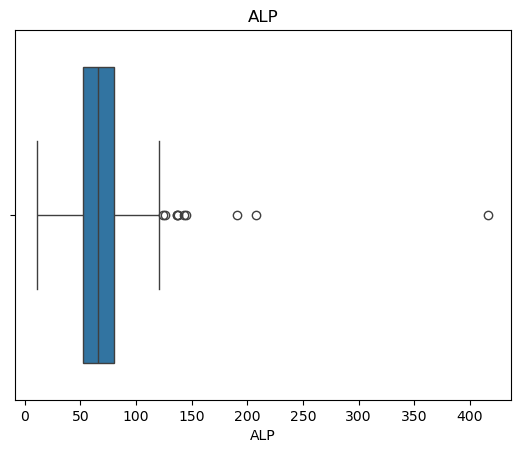

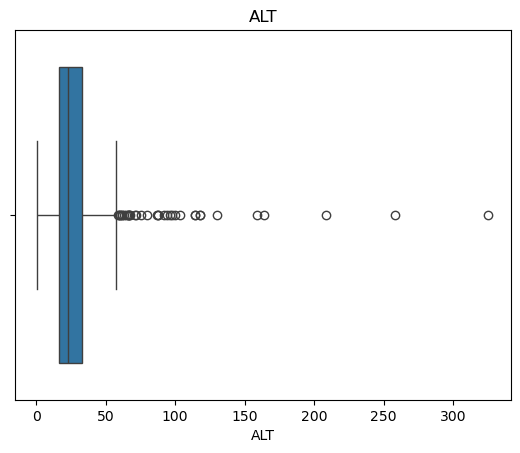

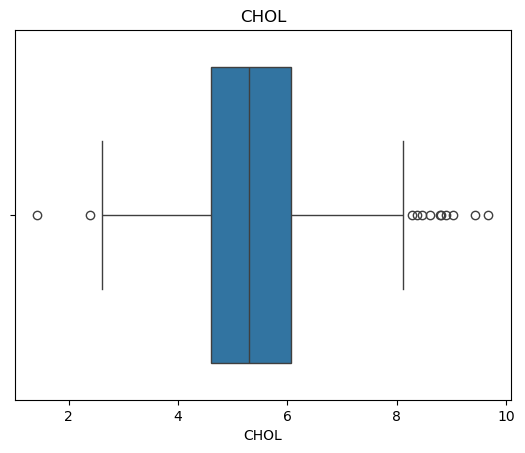

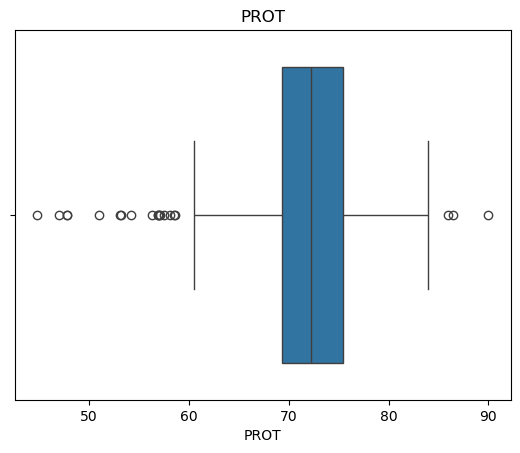

Missign values in column  ALB
0
Missign values in column  ALP
0
Missign values in column  ALT
0
Missign values in column  CHOL
0
Missign values in column  PROT
0


In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


# Create a list of columns with missing values:
col_with_nan = data.isnull().sum()
col_with_nan = col_with_nan[col_with_nan > 0]
print("List of columns with missing values:\n", col_with_nan)

# Check the distribution:
for col in col_with_nan.index:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

# Create an instance of Simple Imputer with strategy set to median
imputer = SimpleImputer(strategy="median")

# Impute missing values for each column
for x in col_with_nan.index:
    data[[x]] = imputer.fit_transform(data[[x]])
    print("Missign values in column ", x)
    print(data[x].isnull().sum())


> We have no more missing data
As an optional thing we can also rename the first column as 'index' or "ID" instead of Unnamed 

In [100]:
data.columns

Index(['Unnamed: 0', 'Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST',
       'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT'],
      dtype='object')

In [101]:
data.rename(columns={'Unnamed: 0': "ID"}, inplace=True)

In [102]:
data.columns

Index(['ID', 'Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL',
       'CHE', 'CHOL', 'CREA', 'GGT', 'PROT'],
      dtype='object')

### 6. Save the clean dataset :

In [103]:
# Don't forget to drop the index 


In [104]:
# Drop the index column
data = data.drop("ID", axis=1)
print(data.info())

# Save clean dataset to file
data.to_csv('clean_HepatitisC.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  615 non-null    int64  
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    int64  
 3   ALB       615 non-null    float64
 4   ALP       615 non-null    float64
 5   ALT       615 non-null    float64
 6   AST       615 non-null    float64
 7   BIL       615 non-null    float64
 8   CHE       615 non-null    float64
 9   CHOL      615 non-null    float64
 10  CREA      615 non-null    float64
 11  GGT       615 non-null    float64
 12  PROT      615 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 62.6 KB
None
